In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
pca_data_abck = pd.read_csv('pca_data_abck.csv')
pca_data_abck.head()

data_fixed = pd.read_csv('data_fixed.csv')
data_fixed.head()

,Unnamed: 0,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc,fecha,referencia
0,0,0.5,1.00,3.0,3.0,2.0,0.68,11.81,1.883,0.05285,4.0,8.20,10.0,41.0,313.0,0.13530,06/04/01,P1
1,1,0.5,1.00,2.2,7.0,2.0,0.18,23.42,5.179,0.16410,4.0,8.36,10.0,185.0,453.0,0.09056,06/04/01,P2
2,2,0.5,1.00,7.0,1.7,2.0,0.48,19.68,6.043,0.20470,4.0,8.47,10.0,209.0,470.0,0.09999,06/04/01,P3
3,3,0.5,1.00,1.1,1.1,2.0,0.58,7.87,3.159,0.09761,4.0,8.34,10.0,74.0,350.0,0.09698,06/04/01,P4
4,4,0.5,2.89,1.3,1.3,2.0,0.35,7.75,1.093,0.03675,5.2,8.44,10.0,0.0,293.0,0.11720,07/04/01,P1


In [46]:
data_fixed["cluster"] = pca_data_abck['cluster_hibrido'].copy()
data_fixed.head()

,Unnamed: 0,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc,fecha,referencia,cluster
0,0,0.5,1.00,3.0,3.0,2.0,0.68,11.81,1.883,0.05285,4.0,8.20,10.0,41.0,313.0,0.13530,06/04/01,P1,1
1,1,0.5,1.00,2.2,7.0,2.0,0.18,23.42,5.179,0.16410,4.0,8.36,10.0,185.0,453.0,0.09056,06/04/01,P2,1
2,2,0.5,1.00,7.0,1.7,2.0,0.48,19.68,6.043,0.20470,4.0,8.47,10.0,209.0,470.0,0.09999,06/04/01,P3,1
3,3,0.5,1.00,1.1,1.1,2.0,0.58,7.87,3.159,0.09761,4.0,8.34,10.0,74.0,350.0,0.09698,06/04/01,P4,1
4,4,0.5,2.89,1.3,1.3,2.0,0.35,7.75,1.093,0.03675,5.2,8.44,10.0,0.0,293.0,0.11720,07/04/01,P1,1


In [47]:
# Calcular el perfil químico de cada cluster
perfil_quimico = data_fixed.drop(columns=['fecha', 'referencia']).groupby('cluster').mean()
display(perfil_quimico)

,Unnamed: 0,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc
cluster,,,,,,,,,,,,,,,,
0,639.000000,10.000000,130.020000,4.800000,4.540000,290.730000,11.000000,26.603000,68.222000,13.662000,355.080000,7.320000,50.710000,680.000000,13710.000000,1.189100
1,315.502471,13.141491,46.199599,3.568768,3.601995,226.618073,44.270295,27.372551,15.592462,1.258686,216.238140,8.052886,80.760957,198.337621,246.249330,0.928542
2,302.000000,6.700000,29.000000,2.300000,7.000000,82.800000,3.525000,7.143000,8.050000,0.680000,170.600000,8.330000,77.300000,284.000000,11.444000,332.000000
3,388.032258,80.987097,84.093174,3.287742,5.499355,492.389768,33.181677,75.308606,106.041615,30.672001,240.118781,6.694903,244.605781,236.713052,89.233065,6.040583


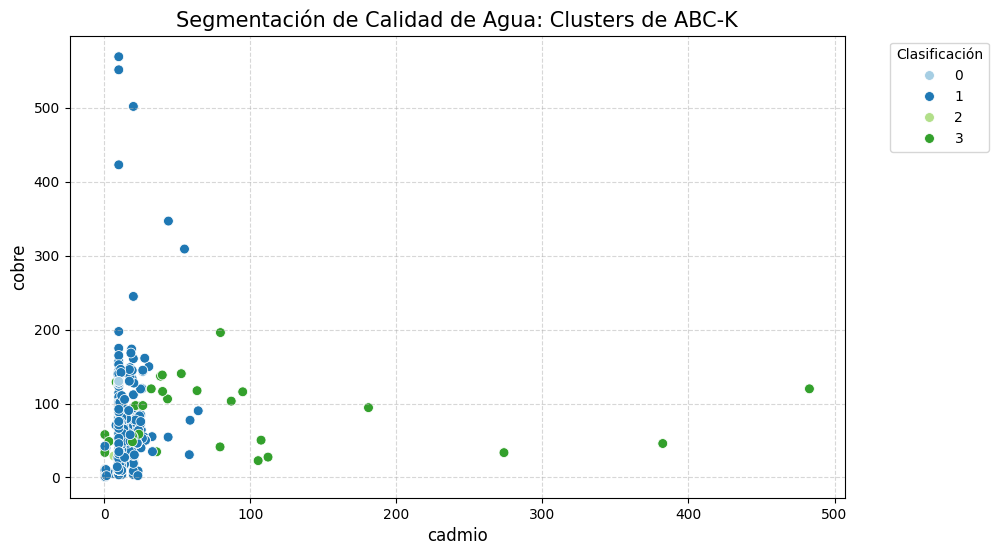

In [57]:
# data_fixed.plot(kind='scatter', x="cadmio", y='cobre', c='cluster', colormap='seismic', legend=True)

pca_labels = ['cadmio', 'cobre']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data_fixed, 
    x=pca_labels[0], 
    y=pca_labels[1], 
    hue='cluster', 
    palette='Paired', 
    s=50, 
    alpha=1,
    edgecolor='w'
)

# Personalización de títulos (basado en tu interpretación de loadings)
plt.title('Segmentación de Calidad de Agua: Clusters de ABC-K', fontsize=15)
plt.xlabel(f'{pca_labels[0]}', fontsize=12)
plt.ylabel(f'{pca_labels[1]}', fontsize=12)
plt.legend(title='Clasificación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.50)
plt.show()
